In [1]:
# SOC ConvNetM — Norm Ablation Study
## Block structure: `SOCConv2d → NormLayer → MaxMin`

# **Experiment matrix:**
# - **Model:** ConvNetM (width w=128, ~12 conv layers)
# - **Conv:** SOC (Skew Orthogonal Convolution)
# - **Activation:** MaxMin (fixed, every layer)
# - **Norm position:** Post-conv, pre-activation (Position A)
# - **Norm conditions:** `None` | `center` | `layer` | `ibnorm`
# - **Datasets:** CIFAR-10, CIFAR-100
# - **Seeds:** 3 per condition → **24 total runs**
# - **Loss:** HKR (LipCrossEntropyLoss) | **Optimizer:** SGD, momentum=0.9 | **ε:** 36/255

# **Codebase:** [berndprach/1LipschitzLayersCompared](https://github.com/berndprach/1LipschitzLayersCompared)

## Cell 1 — Install dependencies

In [2]:
# Install the lipnn package from the official repo
%pip install git+https://github.com/berndprach/1LipschitzLayersCompared.git -q
%pip install einops -q

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


## Cell 2 — Imports

In [3]:
print("M")
import math
import copy
import time
import json
import itertools
from collections import OrderedDict
from typing import Optional, Type, Callable
from tqdm.auto import tqdm
print("H")
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── from berndprach/1LipschitzLayersCompared (lipnn package) ──────────────────
from lipnn.layers.lipschitz.soc import SOC            # SOCConv2d
from lipnn.layers.activations.max_min import MaxMin   # MaxMin activation
from lipnn.layers.basic.zero_channel_pad import ZeroChannelPad
from lipnn.layers.basic.first_channels import FirstChannels
# ─────────────────────────────────────────────────────────────────────────────

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

M
H


/home/administrator/miniconda3/envs/myenv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch: 2.10.0
CUDA available: True
Device: cuda


## Cell 3 — Norm layers

Four normalization conditions, placed **post-conv / pre-activation** (Position A).

### IBNorm — Jacobian analysis
IBNorm mixes **Instance Norm** (IN, applied to first half of channels) and **Batch Norm** (BN, applied to second half).  
The Jacobian of IN with respect to its input `x` (shape `[B,C,H,W]`, treating one sample) is:

$$J_{\text{IN}} = \frac{1}{\sigma} \left( I - \frac{1}{N} \mathbf{1}\mathbf{1}^\top - \frac{(x-\mu)(x-\mu)^\top}{\sigma^2 N} \right)$$

where $N = H \times W$.  This is a projection (idempotent) scaled by $1/\sigma$, so its operator norm can be ≤ 1 when $\sigma \ge 1$ but is **not** generally 1-Lipschitz.  
BN (fixed at eval statistics) has the same structure but over the batch axis.  
Since we use `affine=False` for both, there are **no learnable parameters**, preserving the 1-Lipschitz guarantee for the conv-only path; the norm layer itself may expand norms during training, which is the ablation we study.


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# Normalization layers
# ─────────────────────────────────────────────────────────────────────────────

class CenterNorm(nn.Module):
    """
    Subtracts the per-channel mean (over spatial dims + batch).
    Fixed γ=1, β=0 — no learnable parameters.
    """
    def __init__(self, num_channels: int):
        super().__init__()
        self.num_channels = num_channels

    def forward(self, x: Tensor) -> Tensor:
        # mean over spatial dims only, keep channel dim
        mean = x.mean(dim=(2, 3), keepdim=True)  # [B, C, 1, 1]
        return x - mean


class OneLipschitzLayerNorm(nn.Module):
    """
    Implementation Option 1 — Bounded Standard LayerNorm (1-Lipschitz).

    Standard LayerNorm has Lip <= ||gamma||_inf / sqrt(eps).
    We enforce ||gamma||_inf <= sqrt(eps) via:
        gamma = sqrt(eps) * tanh(theta)
    giving Lip <= 1 unconditionally.

    Applied over the channel dim per spatial position: [B,C,H,W] → permute
    to [B,H,W,C], normalise on last dim, permute back.

    Note: with small eps (e.g. 1e-5), max |gamma_i| ≈ 0.00316, which
    makes outputs small. Correct but restrictive — see Option 2B below.
    """
    def __init__(self, num_channels: int, eps: float = 1e-5, bias: bool = True):
        super().__init__()
        self.num_channels = num_channels
        self.eps = eps
        self.raw_gamma = nn.Parameter(torch.ones(num_channels))
        if bias:
            self.beta = nn.Parameter(torch.zeros(num_channels))
        else:
            self.register_parameter("beta", None)

    def forward(self, x: Tensor) -> Tensor:
        x = x.permute(0, 2, 3, 1)                          # [B, H, W, C]
        mean = x.mean(dim=-1, keepdim=True)
        centered = x - mean
        var = centered.pow(2).mean(dim=-1, keepdim=True)
        normalized = centered / torch.sqrt(var + self.eps)
        gamma = (self.eps ** 0.5) * torch.tanh(self.raw_gamma)  # ||gamma||_inf <= sqrt(eps)
        y = normalized * gamma
        if self.beta is not None:
            y = y + self.beta
        return y.permute(0, 3, 1, 2)                        # [B, C, H, W]


class OneLipschitzCenteredFloorNorm(nn.Module):
    """
    Implementation Option 2B — Centered Floor LayerNorm-style (1-Lipschitz).

    Forward map (per spatial position, over channel dim):
        centered = x - mean(x)           # 1-Lipschitz orthogonal projection
        f(x)     = centered / max(||centered||_2, 1)   # 1-Lipschitz projection onto unit ball

    Composition of two 1-Lipschitz maps → 1-Lipschitz overall.

    With affine scale gamma = tanh(theta), ||gamma||_inf <= 1, so the
    full layer remains 1-Lipschitz. Much more practical than Option 1:
    outputs stay O(1) regardless of eps.

    Applied over the channel dim per spatial position: [B,C,H,W] → permute
    to [B,H,W,C], normalise on last dim, permute back.
    """
    def __init__(self, num_channels: int, bias: bool = True):
        super().__init__()
        self.num_channels = num_channels
        self.raw_gamma = nn.Parameter(torch.full((num_channels,), 3.0))
        if bias:
            self.beta = nn.Parameter(torch.zeros(num_channels))
        else:
            self.register_parameter("beta", None)

    def forward(self, x: Tensor) -> Tensor:
        x = x.permute(0, 2, 3, 1)                          # [B, H, W, C]
        mean = x.mean(dim=-1, keepdim=True)
        centered = x - mean
        norm = torch.linalg.vector_norm(centered, ord=2, dim=-1, keepdim=True)
        rms = norm / math.sqrt(self.num_channels)            # ||Cx||_2 / sqrt(C) = RMS
        denom = torch.clamp(rms, min=1.0)                    # max(RMS, 1)
        normalized = centered / denom
        gamma = torch.tanh(self.raw_gamma)                  # ||gamma||_inf <= 1
        y = normalized * gamma
        if self.beta is not None:
            y = y + self.beta
        return y.permute(0, 3, 1, 2)                        # [B, C, H, W]


class IBNorm(nn.Module):
    """
    Instance-Batch Normalization (IBN).

    Jacobian note (see Cell 3 markdown):
      • First  half of channels → InstanceNorm2d (spatial whitening per sample)
      • Second half of channels → BatchNorm2d    (batch whitening)
    Both use affine=False so there are no learnable params,
    preserving the 1-Lipschitz property of the conv layer.
    The Jacobian of each norm is a projection / scaled-identity;
    the operator norm is data-dependent (≤ 1/σ), which we ablate.
    """
    def __init__(self, num_channels: int):
        super().__init__()
        assert num_channels % 2 == 0, "IBNorm requires even channel count."
        half = num_channels // 2
        # Instance norm on first half — per-sample, per-channel spatial norm
        self.in_norm  = nn.InstanceNorm2d(half, affine=False)
        # Batch norm on second half — batch-level, per-channel norm
        self.bn_norm  = nn.BatchNorm2d(half, affine=False)
        self.half = half

    def forward(self, x: Tensor) -> Tensor:
        x_in = self.in_norm(x[:, :self.half])   # InstanceNorm on first half
        x_bn = self.bn_norm(x[:, self.half:])   # BatchNorm   on second half
        return torch.cat([x_in, x_bn], dim=1)


def get_norm_layer(norm_type: Optional[str], num_channels: int) -> nn.Module:
    """
    Factory for norm layers.

    norm_type=None        → nn.Identity()        (bit-identical to original repo output)
    norm_type='center'    → CenterNorm
    norm_type='lip_ln'    → OneLipschitzLayerNorm    (Option 1:  constrained standard LN)
    norm_type='lip_floor' → OneLipschitzCenteredFloorNorm (Option 2B: centered floor norm)
    norm_type='ibnorm'    → IBNorm
    """
    if norm_type is None:
        return nn.Identity()
    elif norm_type == 'center':
        return CenterNorm(num_channels)
    elif norm_type == 'lip_ln':
        return OneLipschitzLayerNorm(num_channels)
    elif norm_type == 'lip_floor':
        return OneLipschitzCenteredFloorNorm(num_channels)
    elif norm_type == 'ibnorm':
        return IBNorm(num_channels)
    else:
        raise ValueError(f"Unknown norm_type: {norm_type!r}. "
                         "Choose from [None, 'center', 'lip_ln', 'lip_floor', 'ibnorm'].")


print("Norm layers defined.")
# Quick sanity check
_x = torch.randn(4, 8, 8, 8)
for nt in [None, 'center', 'lip_ln', 'lip_floor', 'ibnorm']:
    _out = get_norm_layer(nt, 8)(_x)
    print(f"  norm_type={str(nt):10s}  out.shape={tuple(_out.shape)}")

Norm layers defined.
  norm_type=None        out.shape=(4, 8, 8, 8)
  norm_type=center      out.shape=(4, 8, 8, 8)
  norm_type=lip_ln      out.shape=(4, 8, 8, 8)
  norm_type=lip_floor   out.shape=(4, 8, 8, 8)
  norm_type=ibnorm      out.shape=(4, 8, 8, 8)


## Cell 4 — Modified ConvBlock and ConvNetM

Each block follows **Position A**: `SOCConv2d → NormLayer → MaxMin`  
When `norm_type=None`, the Identity layer produces output **bit-identical** to the original repo.

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# Modified ConvBlock: SOCConv2d(in,out,k=3) → NormLayer(out) → MaxMin()
# ─────────────────────────────────────────────────────────────────────────────

class NormConvBlock(nn.Sequential):
    """
    Replaces the original ConvBlock from simplified_conv_net.py.
    Each layer in the block is: SOC → NormLayer → MaxMin.
    Ends with FirstChannels + PixelUnshuffle (identical to original).

    norm_type=None produces bit-identical output to the original repo
    (Identity() is a no-op with no extra computation).
    """
    def __init__(
        self,
        in_channels: int,
        length: int,
        kernel_size: int,
        norm_type: Optional[str] = None,
    ):
        layers = []
        for _ in range(length):
            # SOCConv2d (same-channel, preserves spatial size)
            layers.append(SOC(in_channels, in_channels, kernel_size))
            # NormLayer — Position A: post-conv, pre-activation
            layers.append(get_norm_layer(norm_type, in_channels))
            # MaxMin activation
            layers.append(MaxMin())
        # Downsample: keep first half of channels, then PixelUnshuffle(2)
        layers.append(FirstChannels(in_channels // 2))
        layers.append(nn.PixelUnshuffle(2))
        super().__init__(*layers)


# ─────────────────────────────────────────────────────────────────────────────
# ConvNetM with norm_type argument
# Architecture mirrors simplified_conv_net.py → SimplifiedConvNet(ConvNetM)
#   base_width=64, nrof_blocks=5, nrof_layers_per_block=5, kernel_size=3
# With w=128 override as specified (base_width=128)
# ─────────────────────────────────────────────────────────────────────────────

class ConvNetM(nn.Sequential):
    """
    ConvNetM — width w=128, ~12 conv layers.
    Block structure: SOCConv2d → NormLayer → MaxMin  (Position A)

    Parameters
    ----------
    norm_type   : None | 'center' | 'layer' | 'ibnorm'
    nrof_classes: 10 (CIFAR-10) or 100 (CIFAR-100)
    seed        : reproducibility seed
    """
    # ConvNetM defaults from the repo's DEFAULT_MODELS
    BASE_WIDTH          = 128   # w=128 as specified
    NROF_BLOCKS         = 5
    NROF_LAYERS_PER_BLOCK = 5
    KERNEL_SIZE         = 3

    def __init__(
        self,
        norm_type: Optional[str] = None,
        nrof_classes: int = 10,
        seed: Optional[int] = None,
    ):
        if seed is not None:
            torch.manual_seed(seed)

        self.norm_type    = norm_type
        self.nrof_classes = nrof_classes

        bw   = self.BASE_WIDTH
        nb   = self.NROF_BLOCKS
        nlpb = self.NROF_LAYERS_PER_BLOCK
        ks   = self.KERNEL_SIZE

        # kernel_size of last block must be 1 (2×2 spatial size)
        kernel_sizes = [ks] * nb
        kernel_sizes[-1] = 1

        # ── build layers (mirrors get_layers() in simplified_conv_net.py) ──
        block_layers = [
            # Input padding: 3 → base_width channels
            ("ZeroConcatenation", ZeroChannelPad(bw)),
            # First 1×1 conv (no norm here — matches original)
            ("FirstConv",   SOC(bw, bw, 1)),
            ("FirstNorm",   get_norm_layer(norm_type, bw)),
            ("FirstActivation", MaxMin()),
        ]

        # Downsize blocks
        for i in range(nb):
            ch = bw * (2 ** i)
            block_layers.append((
                f"Block{i+1}",
                NormConvBlock(ch, nlpb, kernel_sizes[i], norm_type=norm_type)
            ))

        # Classification head
        in_features = bw * (2 ** nb)
        block_layers += [
            ('AdaptiveMaxPool', nn.AdaptiveMaxPool2d(1)),
            ('ClassificationHead', nn.Sequential(
                SOC(in_features, in_features, 1),
                nn.Flatten(),
            )),
            ("FirstChannels", FirstChannels(nrof_classes)),
        ]

        super().__init__(OrderedDict(block_layers))

    def extra_repr(self) -> str:
        return (f"norm_type={self.norm_type!r}, "
                f"nrof_classes={self.nrof_classes}")


# ── Quick architecture sanity check ─────────────────────────────────────────
print("Building ConvNetM with norm_type=None (bit-identical to original)...")
_model_none = ConvNetM(norm_type=None, nrof_classes=10, seed=0)
_x_test = torch.randn(2, 3, 32, 32)
_y_test = _model_none(_x_test)
print(f"  Input:  {tuple(_x_test.shape)}")
print(f"  Output: {tuple(_y_test.shape)}")
n_params = sum(p.numel() for p in _model_none.parameters() if p.requires_grad)
print(f"  Trainable params: {n_params:,}")

print("\nBuilding ConvNetM for all norm_types...")
for nt in [None, 'center', 'lip_ln', 'lip_floor'  , 'ibnorm']:
    m = ConvNetM(norm_type=nt, nrof_classes=10, seed=0)
    out = m(torch.randn(2, 3, 32, 32))
    np_ = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f"  norm_type={str(nt):8s}  out={tuple(out.shape)}  params={np_:,}")
print("\nAll norm conditions OK.")

Building ConvNetM with norm_type=None (bit-identical to original)...
  Input:  (2, 3, 32, 32)
  Output: (2, 10)
  Trainable params: 100,457,984

Building ConvNetM for all norm_types...
  norm_type=None      out=(2, 10)  params=100,457,984
  norm_type=center    out=(2, 10)  params=100,457,984
  norm_type=lip_ln    out=(2, 10)  params=100,497,920
  norm_type=lip_floor  out=(2, 10)  params=100,497,920
  norm_type=ibnorm    out=(2, 10)  params=100,457,984

All norm conditions OK.


## Cell 5 — HKR Loss (LipCrossEntropyLoss)

Directly ported from `trainer/metrics/lipschit_ce_loss.py` in the repo.

In [6]:
class HKRLoss(nn.Module):
    """
    Hinge-Kl Regularization (HKR) loss.
    Ported from trainer/metrics/lipschit_ce_loss.py (LipCrossEntropyLoss).

    Subtracts `margin` from the true-class logit before cross-entropy,
    then rescales by temperature (temperature-scaled HKR).

    Default hyper-params from settings/defaults_CIFAR10.yml:
        margin=0.3993, temperature=0.25
    """
    def __init__(self, margin: float = 0.3993, temperature: float = 0.25):
        super().__init__()
        self.margin      = margin
        self.temperature = temperature

    def forward(self, inputs: Tensor, labels: Tensor) -> Tensor:
        # Subtract margin from the true-class logit
        margin = torch.full_like(labels, self.margin,
                                 dtype=inputs.dtype).unsqueeze(1)
        out = inputs.scatter_add(dim=-1,
                                 index=labels.unsqueeze(1),
                                 src=-margin)
        # Temperature-scaled cross-entropy (matches LipCrossEntropyLoss exactly)
        return F.cross_entropy(out / self.temperature,
                               labels) * self.temperature


# Verify the loss produces finite output
_logits = torch.randn(8, 10)
_labels = torch.randint(0, 10, (8,))
_loss_val = HKRLoss()(_logits, _labels)
print(f"HKR loss sanity check: {_loss_val.item():.4f}  (should be finite)")

HKR loss sanity check: 1.8262  (should be finite)


## Cell 6 — Dataset loader (CIFAR-10 / CIFAR-100)

In [7]:
def get_cifar_loaders(
    dataset: str = 'cifar10',
    batch_size: int = 256,
    num_workers: int = 2,
    data_root: str = './data',
):
    """
    Returns (train_loader, test_loader) for CIFAR-10 or CIFAR-100.
    Centering transform matches settings/defaults_CIFAR10.yml (center: True).
    """
    assert dataset in ('cifar10', 'cifar100')

    # Per-channel means for centering (from torchvision standard stats)
    if dataset == 'cifar10':
        mean = (0.4914, 0.4822, 0.4465)
        std  = (1.0, 1.0, 1.0)   # center=True, no std scaling
        cls  = torchvision.datasets.CIFAR10
        nrof_classes = 10
    else:
        mean = (0.5071, 0.4867, 0.4408)
        std  = (1.0, 1.0, 1.0)
        cls  = torchvision.datasets.CIFAR100
        nrof_classes = 100

    train_transform = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])
    test_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])

    trainset = cls(root=data_root, train=True,  download=True, transform=train_transform)
    testset  = cls(root=data_root, train=False, download=True, transform=test_transform)

    train_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True,
                              num_workers=num_workers, pin_memory=True)
    test_loader  = DataLoader(testset,  batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=True)

    return train_loader, test_loader, nrof_classes


print("Data loader factory ready.")

Data loader factory ready.


## Cell 7 — Certified Robust Accuracy (CRA) helper

For a 1-Lipschitz network with margin `m` and ε-budget, a sample `x` is **certifiably robust** if:

$$f_{y^*}(x) - \max_{j \ne y^*} f_j(x) > 2\varepsilon$$

We use **ε = 36/255** as specified.

In [8]:
EPSILON = 36 / 255

@torch.no_grad()
def evaluate(
    model: nn.Module,
    loader: DataLoader,
    loss_fn: nn.Module,
    epsilon: float = EPSILON,
    device: torch.device = DEVICE,
    use_tqdm: bool = False,
):
    model.eval()
    total_loss, correct, certified, total = 0.0, 0, 0, 0

    pbar = tqdm(loader, desc="Evaluate", leave=False) if use_tqdm else loader
    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)
        logits = model(inputs)
        loss   = loss_fn(logits, labels)

        pred = logits.argmax(dim=1)
        correct += (pred == labels).sum().item()

        true_logit = logits.gather(1, labels.unsqueeze(1)).squeeze(1)
        logits_masked = logits.clone()
        logits_masked.scatter_(1, labels.unsqueeze(1), float('-inf'))
        best_other = logits_masked.max(dim=1).values
        margin = true_logit - best_other
        # FIXED: correct certificate for 1-Lipschitz nets is margin > sqrt(2) * epsilon
        certified += (margin > math.sqrt(2) * epsilon).sum().item()

        total_loss += loss.item() * inputs.size(0)
        total      += inputs.size(0)

    return dict(
        loss     = total_loss / total,
        accuracy = 100.0 * correct   / total,
        cra      = 100.0 * certified / total,
    )

print(f"Evaluation function ready. ε = {EPSILON:.4f} ({36}/255), threshold = √2·ε = {math.sqrt(2)*EPSILON:.4f}")

Evaluation function ready. ε = 0.1412 (36/255), threshold = √2·ε = 0.1997


## Cell 8 — Training function

In [9]:
import functools
import itertools as it

# ─────────────────────────────────────────────────────────────────────────────
# Timing helpers — ported from evaluator/batch_times.py
# ─────────────────────────────────────────────────────────────────────────────

def _forward_pass_timed(model, batch, device):
    batch = batch.to(device)
    out   = model(batch)
    out.sum()


def _backward_pass_timed(model, optimizer, batch, device):
    batch = batch.to(device)
    out   = model(batch)
    out.sum().backward()
    optimizer.step()


def measure_batch_times(model, train_loader, test_loader,
                        nrof_batches=50, device=DEVICE):
    """
    Ported from evaluator/batch_times.py → evaluate_all_model_time_statistics.
    Returns mean/std of per-batch train time and inference time (seconds).
    First batch is skipped (warm-up), matching the repo's [1:] slicing.
    """
    # ── Train batch times ─────────────────────────────────────────────────
    model.train()
    model.to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=1e-3, momentum=0.9)
    train_times = []
    for i, (batch, _) in enumerate(it.cycle(train_loader)):
        if i >= nrof_batches + 1:
            break
        t0 = time.time()
        _backward_pass_timed(model, optimizer, batch, device)
        train_times.append(time.time() - t0)

    # ── Inference batch times ──────────────────────────────────────────────
    model.eval()
    inf_times = []
    with torch.no_grad():
        for i, (batch, _) in enumerate(it.cycle(test_loader)):
            if i >= nrof_batches + 1:
                break
            t0 = time.time()
            _forward_pass_timed(model, batch, device)
            inf_times.append(time.time() - t0)

    # Skip first batch (warm-up) — matches repo's train_batch_times[1:]
    train_arr = np.array(train_times[1:])
    inf_arr   = np.array(inf_times[1:])

    return dict(
        train_time_mean = float(train_arr.mean()),
        train_time_std  = float(train_arr.std()),
        inf_time_mean   = float(inf_arr.mean()),
        inf_time_std    = float(inf_arr.std()),
    )


# ─────────────────────────────────────────────────────────────────────────────
# Memory helpers — ported from evaluator/memory_usage.py
# ─────────────────────────────────────────────────────────────────────────────

def _bytes_to_str(n):
    if n > 1e9: return f"{n/1e9:.2f} GB"
    if n > 1e6: return f"{n/1e6:.2f} MB"
    if n > 1e3: return f"{n/1e3:.2f} KB"
    return f"{n} B"


def measure_memory(model, train_loader, test_loader, device=DEVICE):
    """
    Ported from evaluator/memory_usage.py → get_model_memory.
    Returns peak CUDA memory for inference and training passes (bytes).
    Falls back to CPU tracemalloc estimate if CUDA is unavailable.
    """
    if not torch.cuda.is_available():
        import tracemalloc
        results = {}

        # Inference memory
        model.eval()
        tracemalloc.start()
        with torch.no_grad():
            for i, (batch, _) in enumerate(test_loader):
                _ = model(batch)
                if i >= 2: break
        _, inf_peak = tracemalloc.get_traced_memory()
        tracemalloc.stop()
        results['inf_memory_bytes'] = inf_peak
        results['inf_memory_str']   = _bytes_to_str(inf_peak)

        # Train memory
        model.train()
        optimizer = torch.optim.SGD(model.parameters(), lr=1e-3, momentum=0.9)
        tracemalloc.start()
        for i, (batch, labels) in enumerate(train_loader):
            out = model(batch)
            out.sum().backward()
            optimizer.step()
            if i >= 2: break
        _, train_peak = tracemalloc.get_traced_memory()
        tracemalloc.stop()
        results['train_memory_bytes'] = train_peak
        results['train_memory_str']   = _bytes_to_str(train_peak)
        return results

    # ── CUDA path (matches repo exactly) ──────────────────────────────────
    results = {}

    # Inference memory
    model.eval()
    model.to(device)
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    pre = torch.cuda.max_memory_allocated()
    with torch.no_grad():
        for i, (batch, _) in enumerate(test_loader):
            batch = batch.to(device)
            out   = model(batch)
            out.sum()
            del batch, out
            if i >= 2: break
    inf_mem = torch.cuda.max_memory_allocated() - pre
    results['inf_memory_bytes'] = inf_mem
    results['inf_memory_str']   = _bytes_to_str(inf_mem)

    # Train memory
    model.train()
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    pre       = torch.cuda.max_memory_allocated()
    optimizer = torch.optim.SGD(model.parameters(), lr=1e-3, momentum=0.9)
    for i, (batch, _) in enumerate(train_loader):
        batch = batch.to(device)
        out   = model(batch)
        out.sum().backward()
        optimizer.step()
        del batch, out
        if i >= 2: break
    train_mem = torch.cuda.max_memory_allocated() - pre
    results['train_memory_bytes'] = train_mem
    results['train_memory_str']   = _bytes_to_str(train_mem)

    return results


# ─────────────────────────────────────────────────────────────────────────────
# Gradient norm + Lipschitz helpers
# ─────────────────────────────────────────────────────────────────────────────

def log_layer_norm_gamma(model: nn.Module, epoch: int):
    """Log spectral norm of γ for all LayerNorm layers (verifies Proposition 2)."""
    for name, module in model.named_modules():
        if isinstance(module, nn.LayerNorm) and module.weight is not None:
            gamma_norm = module.weight.data.norm(2).item()
            tqdm.write(f"  [Ep {epoch}] LayerNorm γ ‖γ‖₂ = {gamma_norm:.4f}  ({name})")


def measure_empirical_lipschitz(model, n_pairs=100,
                                 input_shape=(3, 32, 32), device=DEVICE):
    """
    Estimate empirical Lipschitz constant via random input pairs.
    Required by plan Section 4.3 / 10.3 for IBNorm tightness verification.
    """
    model.eval()
    with torch.no_grad():
        max_ratio = 0.0
        for _ in range(n_pairs):
            x1 = torch.randn(1, *input_shape, device=device)
            x2 = torch.randn(1, *input_shape, device=device)
            diff_in  = (x1 - x2).norm().item()
            if diff_in < 1e-8:
                continue
            diff_out = (model(x1) - model(x2)).norm().item()
            max_ratio = max(max_ratio, diff_out / diff_in)
    return max_ratio


# ─────────────────────────────────────────────────────────────────────────────
# train_one_epoch
# ─────────────────────────────────────────────────────────────────────────────

def train_one_epoch(model, loader, optimizer, scheduler, loss_fn,
                    device=DEVICE, use_tqdm=False, epoch=None):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    total_grad_norm = 0.0
    n_batches       = 0

    desc = f"Epoch {epoch}" if epoch is not None else "Train"
    pbar = tqdm(loader, desc=desc, leave=False) if use_tqdm else loader
    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(inputs)
        loss   = loss_fn(logits, labels)
        loss.backward()

        batch_grad_norm = 0.0
        for p in model.parameters():
            if p.grad is not None:
                batch_grad_norm += p.grad.data.norm(2).item() ** 2
        batch_grad_norm  = batch_grad_norm ** 0.5
        total_grad_norm += batch_grad_norm
        n_batches       += 1

        optimizer.step()
        if scheduler is not None:
            scheduler.step()

        pred       = logits.argmax(dim=1)
        correct    += (pred == labels).sum().item()
        total_loss += loss.item() * inputs.size(0)
        total      += inputs.size(0)

    return dict(
        loss      = total_loss / total,
        accuracy  = 100.0 * correct / total,
        grad_norm = total_grad_norm / n_batches,
    )


# ─────────────────────────────────────────────────────────────────────────────
# run_experiment — measures timing and memory once before training
# ─────────────────────────────────────────────────────────────────────────────

def run_experiment(
    norm_type:    Optional[str],
    dataset:      str,
    seed:         int,
    num_epochs:   int   = 1,
    batch_size:   int   = 256,
    lr:           float = 0.01,
    weight_decay: float = 5e-4,
    margin:       float = 0.3993,
    temperature:  float = 0.25,
    data_root:    str   = './data',
    device:       torch.device = DEVICE,
    verbose:      bool  = True,
    nrof_time_batches: int = 50,
) -> dict:

    torch.manual_seed(seed)
    np.random.seed(seed)

    run_id      = f"{dataset}__norm={norm_type}__seed={seed}"
    safe_run_id = run_id.replace('=', '_').replace('/', '_')
    if verbose:
        print(f"\n{'='*60}")
        print(f"  RUN: {run_id}")
        print(f"{'='*60}")

    train_loader, test_loader, nrof_classes = get_cifar_loaders(
        dataset=dataset, batch_size=batch_size, data_root=data_root
    )

    model = ConvNetM(
        norm_type=norm_type,
        nrof_classes=nrof_classes,
        seed=seed,
    ).to(device)

    loss_fn = HKRLoss(margin=margin, temperature=temperature)

    # ── Measure timing and memory BEFORE training starts ──────────────────
    if verbose:
        print("  Measuring batch times and memory...")

    time_stats   = measure_batch_times(
        model, train_loader, test_loader,
        nrof_batches=nrof_time_batches, device=device
    )
    memory_stats = measure_memory(
        model, train_loader, test_loader, device=device
    )

    if verbose:
        print(f"  Train time/batch : "
              f"{time_stats['train_time_mean']*1000:.2f} ms "
              f"± {time_stats['train_time_std']*1000:.2f} ms")
        print(f"  Inf   time/batch : "
              f"{time_stats['inf_time_mean']*1000:.2f} ms "
              f"± {time_stats['inf_time_std']*1000:.2f} ms")
        print(f"  Train memory     : {memory_stats['train_memory_str']}")
        print(f"  Inf   memory     : {memory_stats['inf_memory_str']}")

    # Re-initialise model cleanly for training after measurement
    torch.manual_seed(seed)
    model = ConvNetM(
        norm_type=norm_type,
        nrof_classes=nrof_classes,
        seed=seed,
    ).to(device)

    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=lr,
        momentum=0.9,
        weight_decay=weight_decay,
        nesterov=False,
    )

    steps_per_epoch = len(train_loader)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=lr,
        epochs=num_epochs,
        steps_per_epoch=steps_per_epoch,
    )

    history  = []
    best_cra = 0.0
    t0       = time.time()

    epoch_iter = tqdm(range(1, num_epochs + 1), desc=run_id, unit="ep") if verbose else range(1, num_epochs + 1)
    for epoch in epoch_iter:
        train_metrics = train_one_epoch(
            model, train_loader, optimizer, scheduler, loss_fn, device,
            use_tqdm=False, epoch=epoch
        )
        val_metrics = evaluate(model, test_loader, loss_fn, device=device, use_tqdm=False)
        best_cra    = max(best_cra, val_metrics['cra'])
        if verbose and hasattr(epoch_iter, 'set_postfix'):
            epoch_iter.set_postfix(
                loss=f"{train_metrics['loss']:.3f}",
                acc=f"{train_metrics['accuracy']:.1f}%",
                cra=f"{val_metrics['cra']:.1f}%",
            )

        emp_lip = None
        if epoch % 10 == 0:
            if norm_type == 'layer':
                log_layer_norm_gamma(model, epoch)
            emp_lip = measure_empirical_lipschitz(
                model, n_pairs=100, device=device
            )
            if verbose:
                tqdm.write(f"  [Ep {epoch}] Empirical Lipschitz ≈ {emp_lip:.4f}")

        record = dict(
            epoch         = epoch,
            run_id        = run_id,
            norm_type     = str(norm_type),
            dataset       = dataset,
            seed          = seed,
            **{f'train_{k}': v for k, v in train_metrics.items()},
            **{f'val_{k}':   v for k, v in val_metrics.items()},
            empirical_lip = emp_lip,
            elapsed       = time.time() - t0,
        )
        history.append(record)

        if epoch % 10 == 0:
            ckpt = dict(
                run_id    = run_id,
                norm_type = str(norm_type),
                dataset   = dataset,
                seed      = seed,
                epoch     = epoch,
                best_cra  = best_cra,
                history   = history,
            )
            with open(
                f'./ckpt_{safe_run_id}_ep{epoch:03d}.json', 'w'
            ) as f:
                json.dump(ckpt, f)

        if verbose and (epoch % 10 == 0 or epoch == 1):
            tqdm.write(f"  Ep {epoch:3d}/{num_epochs} | "
                  f"loss={train_metrics['loss']:.4f} "
                  f"acc={train_metrics['accuracy']:.1f}% | "
                  f"grad={train_metrics['grad_norm']:.4f} | "
                  f"val_acc={val_metrics['accuracy']:.1f}% "
                  f"CRA={val_metrics['cra']:.1f}%")

    final = dict(
        run_id              = run_id,
        norm_type           = str(norm_type),
        dataset             = dataset,
        seed                = seed,
        best_cra            = best_cra,
        final_val_acc       = history[-1]['val_accuracy'],
        final_cra           = history[-1]['val_cra'],
        final_emp_lip       = next(
            (h['empirical_lip'] for h in reversed(history)
             if h['empirical_lip'] is not None), None
        ),
        final_grad_norm     = history[-1]['train_grad_norm'],
        train_time_mean     = time_stats['train_time_mean'],
        train_time_std      = time_stats['train_time_std'],
        inf_time_mean       = time_stats['inf_time_mean'],
        inf_time_std        = time_stats['inf_time_std'],
        train_memory_bytes  = memory_stats['train_memory_bytes'],
        train_memory_str    = memory_stats['train_memory_str'],
        inf_memory_bytes    = memory_stats['inf_memory_bytes'],
        inf_memory_str      = memory_stats['inf_memory_str'],
        total_time          = time.time() - t0,
        history             = history,
    )

    if verbose:
        tqdm.write(f"\n  → Best CRA: {best_cra:.2f}%  "
                   f"Final acc: {history[-1]['val_accuracy']:.2f}%")
    return final


print("Training function ready.")

Training function ready.


## Cell 9 — Experiment configuration (24 runs)

In [10]:
# ── Experiment matrix ─────────────────────────────────────────────────────────
# NORM_TYPES  = [None, 'center', 'layer', 'ibnorm']  # 4 conditions
NORM_TYPES  = [None,'center']
DATASETS    = ['cifar10', 'cifar100']# 2 datasets
# DATASETS    = ['cifar10']
SEEDS       = [0]                             # 3 seeds
# SEEDS       = [0]
# Total: 4 × 2 × 3 = 24 runs ✓

# Training config
TRAIN_CONFIG = dict(
    num_epochs   = 200,     # adjust downward for quick smoke-test
    batch_size   = 256,
    lr           = 0.01,
    weight_decay = 5e-4,
    margin       = 0.3993,  # from defaults_CIFAR10.yml
    temperature  = 0.25,    # from defaults_CIFAR10.yml
    data_root    = './data',
    device       = DEVICE,
    verbose      = True,
)

# Print the full run matrix
print(f"{'Run':>3}  {'Dataset':>10}  {'norm_type':>10}  {'seed':>4}")
print("-" * 40)
run_idx = 1
for dataset, norm_type, seed in itertools.product(DATASETS, NORM_TYPES, SEEDS):
    print(f"{run_idx:>3}  {dataset:>10}  {str(norm_type):>10}  {seed:>4}")
    run_idx += 1
print(f"\nTotal runs: {run_idx - 1}")

Run     Dataset   norm_type  seed
----------------------------------------
  1     cifar10        None     0
  2     cifar10      center     0
  3    cifar100        None     0
  4    cifar100      center     0

Total runs: 4


## Cell 10 — Run all 24 experiments

> **Tip:** For a quick smoke-test set `num_epochs=3` in `TRAIN_CONFIG` above.

In [11]:
all_results = []  # list of per-run result dicts

total_runs = len(DATASETS) * len(NORM_TYPES) * len(SEEDS)
run_count  = 0

for dataset in DATASETS:
    for norm_type in NORM_TYPES:
        for seed in SEEDS:
            run_count += 1
            print(f"\n[{run_count}/{total_runs}] "
                  f"dataset={dataset}  norm_type={norm_type}  seed={seed}")
            result = run_experiment(
                norm_type  = norm_type,
                dataset    = dataset,
                seed       = seed,
                **TRAIN_CONFIG,
            )
            all_results.append(result)

            # Save checkpoint after each run
            checkpoint = [
                {k: v for k, v in r.items() if k != 'history'}
                for r in all_results
            ]
            with open('./results_checkpoint.json', 'w') as f:
                json.dump(checkpoint, f, indent=2)

print("\n✓ All 24 runs complete.")


[1/4] dataset=cifar10  norm_type=None  seed=0

  RUN: cifar10__norm=None__seed=0
  Measuring batch times and memory...
  Train time/batch : 2502.54 ms ± 95.06 ms
  Inf   time/batch : 2065.61 ms ± 195.53 ms
  Train memory     : 11.54 GB
  Inf   memory     : 810.81 MB


cifar10__norm=None__seed=0:   0%|          | 1/200 [09:48<32:32:09, 588.59s/ep, acc=17.9%, cra=0.1%, loss=0.934]

  Ep   1/200 | loss=0.9341 acc=17.9% | grad=1.0067 | val_acc=25.4% CRA=0.1%


cifar10__norm=None__seed=0:   5%|▌         | 10/200 [1:43:23<33:23:45, 632.77s/ep, acc=33.2%, cra=13.4%, loss=0.820]

  [Ep 10] Empirical Lipschitz ≈ 0.0071
  Ep  10/200 | loss=0.8199 acc=33.2% | grad=2.1964 | val_acc=38.3% CRA=13.4%


...

  [Ep 180] Empirical Lipschitz ≈ 0.0482
  Ep 180/200 | loss=1.2358 acc=23.0% | grad=0.8358 | val_acc=19.5% CRA=9.1%


cifar100__norm=center__seed=0:  95%|█████████▌| 190/200 [34:24:55<1:49:31, 657.16s/ep, acc=23.2%, cra=9.3%, loss=1.233]

  [Ep 190] Empirical Lipschitz ≈ 0.0568
  Ep 190/200 | loss=1.2326 acc=23.2% | grad=0.8388 | val_acc=19.6% CRA=9.3%


cifar100__norm=center__seed=0: 100%|██████████| 200/200 [36:13:39<00:00, 652.10s/ep, acc=23.2%, cra=9.2%, loss=1.232]  

  [Ep 200] Empirical Lipschitz ≈ 0.0436
  Ep 200/200 | loss=1.2322 acc=23.2% | grad=0.8404 | val_acc=19.6% CRA=9.2%

  → Best CRA: 9.29%  Final acc: 19.65%

✓ All 24 runs complete.


## Cell 11 — Aggregate results into a DataFrame

In [12]:
summary_rows = []
for r in all_results:
    emp_lip_values = [h['empirical_lip'] for h in r['history']
                      if h['empirical_lip'] is not None]
    final_emp_lip  = emp_lip_values[-1] if emp_lip_values else None

    summary_rows.append(dict(
        dataset             = r['dataset'],
        norm_type           = r['norm_type'],
        seed                = r['seed'],
        best_cra            = r['best_cra'],
        final_val_acc       = r['final_val_acc'],
        final_cra           = r['final_cra'],
        final_emp_lip       = final_emp_lip,
        final_grad_norm     = r['final_grad_norm'],
        train_time_mean     = r['train_time_mean'],
        train_time_std      = r['train_time_std'],
        inf_time_mean       = r['inf_time_mean'],
        inf_time_std        = r['inf_time_std'],
        train_memory_bytes  = r['train_memory_bytes'],
        inf_memory_bytes    = r['inf_memory_bytes'],
        train_memory_str    = r['train_memory_str'],
        inf_memory_str      = r['inf_memory_str'],
        total_time          = r['total_time'],
    ))

df = pd.DataFrame(summary_rows)
print(df.to_string(index=False))

 dataset norm_type  seed  best_cra  final_val_acc  final_cra  final_emp_lip  final_grad_norm  train_time_mean  train_time_std  inf_time_mean  inf_time_std  train_memory_bytes  inf_memory_bytes train_memory_str inf_memory_str    total_time
 cifar10      None     0     52.85          67.63      52.70       0.012052         1.839308         2.502541        0.095056       2.065611      0.195525         11540952576         810812416         11.54 GB      810.81 MB 126431.172340
 cifar10    center     0     34.99          53.77      34.77       0.023478         0.814691         2.806063        0.014339       2.224188      0.208695         11542787584         811860992         11.54 GB      811.86 MB 130282.796010
cifar100      None     0     23.00          36.01      22.86       0.028135         2.024607         2.592697        0.022841       2.083886      0.197141         11541476864         810812416         11.54 GB      810.81 MB 126867.711843
cifar100    center     0      9.29          

## Cell 12 — Mean ± std per condition

In [13]:
def fmt(mean, std, decimals=2):
    fmt_str = f"{{:.{decimals}f}}"
    if pd.notna(std) and std > 0:
        return f"{fmt_str.format(mean)} ± {fmt_str.format(std)}"
    return fmt_str.format(mean) if pd.notna(mean) else "N/A"


agg = df.groupby(['dataset', 'norm_type']).agg(
    mean_acc        = ('final_val_acc',      'mean'),
    std_acc         = ('final_val_acc',      'std'),
    mean_cra        = ('best_cra',           'mean'),
    std_cra         = ('best_cra',           'std'),
    mean_emp_lip    = ('final_emp_lip',      'mean'),
    std_emp_lip     = ('final_emp_lip',      'std'),
    mean_grad       = ('final_grad_norm',    'mean'),
    std_grad        = ('final_grad_norm',    'std'),
    mean_train_time = ('train_time_mean',    'mean'),
    std_train_time  = ('train_time_std',     'mean'),
    mean_inf_time   = ('inf_time_mean',      'mean'),
    std_inf_time    = ('inf_time_std',       'mean'),
    mean_train_mem  = ('train_memory_bytes', 'mean'),
    mean_inf_mem    = ('inf_memory_bytes',   'mean'),
).reset_index()

agg['Clean Acc']     = agg.apply(
    lambda r: fmt(r.mean_acc, r.std_acc), axis=1)
agg['CRA']           = agg.apply(
    lambda r: fmt(r.mean_cra, r.std_cra), axis=1)
agg['Emp. Lip']      = agg.apply(
    lambda r: fmt(r.mean_emp_lip, r.std_emp_lip, 4)
    if pd.notna(r.mean_emp_lip) else "N/A", axis=1)
agg['Grad Norm']     = agg.apply(
    lambda r: fmt(r.mean_grad, r.std_grad, 4), axis=1)
agg['Train t/batch'] = agg.apply(
    lambda r: f"{r.mean_train_time*1000:.1f} ± "
              f"{r.std_train_time*1000:.1f} ms", axis=1)
agg['Inf t/batch']   = agg.apply(
    lambda r: f"{r.mean_inf_time*1000:.1f} ± "
              f"{r.std_inf_time*1000:.1f} ms", axis=1)
agg['Train Mem']     = agg.apply(
    lambda r: _bytes_to_str(r.mean_train_mem)
    if pd.notna(r.mean_train_mem) else "N/A", axis=1)
agg['Inf Mem']       = agg.apply(
    lambda r: _bytes_to_str(r.mean_inf_mem)
    if pd.notna(r.mean_inf_mem) else "N/A", axis=1)

summary_table = agg[['dataset', 'norm_type',
                      'Clean Acc', 'CRA',
                      'Emp. Lip', 'Grad Norm',
                      'Train t/batch', 'Inf t/batch',
                      'Train Mem', 'Inf Mem']]

print(summary_table.to_string(index=False))

df.to_csv('./all_runs.csv', index=False)
summary_table.to_csv('./summary_table.csv', index=False)
print("\nSaved: all_runs.csv, summary_table.csv")

 dataset norm_type Clean Acc   CRA Emp. Lip Grad Norm    Train t/batch       Inf t/batch Train Mem   Inf Mem
 cifar10      None     67.63 52.85   0.0121    1.8393 2502.5 ± 95.1 ms 2065.6 ± 195.5 ms  11.54 GB 810.81 MB
 cifar10    center     53.77 34.99   0.0235    0.8147 2806.1 ± 14.3 ms 2224.2 ± 208.7 ms  11.54 GB 811.86 MB
cifar100      None     36.01 23.00   0.0281    2.0246 2592.7 ± 22.8 ms 2083.9 ± 197.1 ms  11.54 GB 810.81 MB
cifar100    center     19.65  9.29   0.0436    0.8404 2834.7 ± 18.0 ms 2252.9 ± 209.4 ms  11.54 GB 810.81 MB

Saved: all_runs.csv, summary_table.csv


## Cell 13 — Visualizations

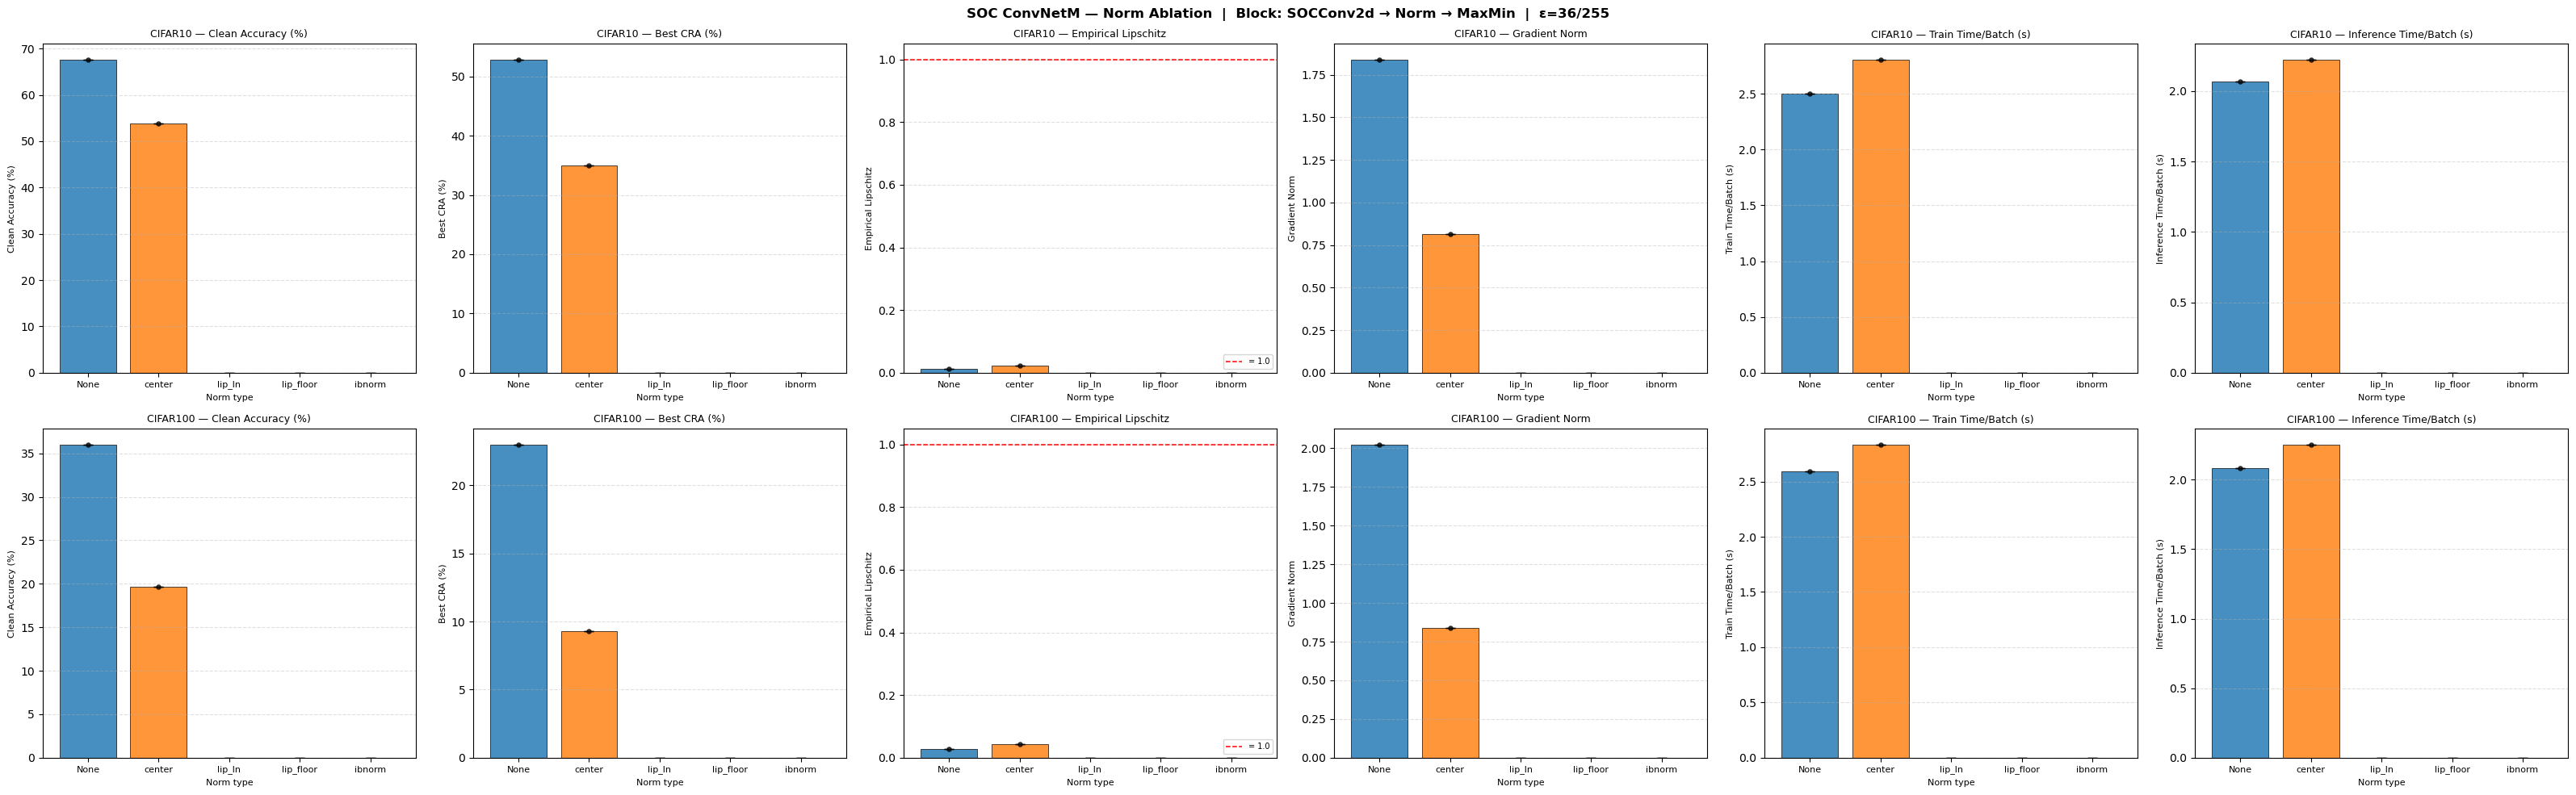

Saved: norm_ablation_bar.png


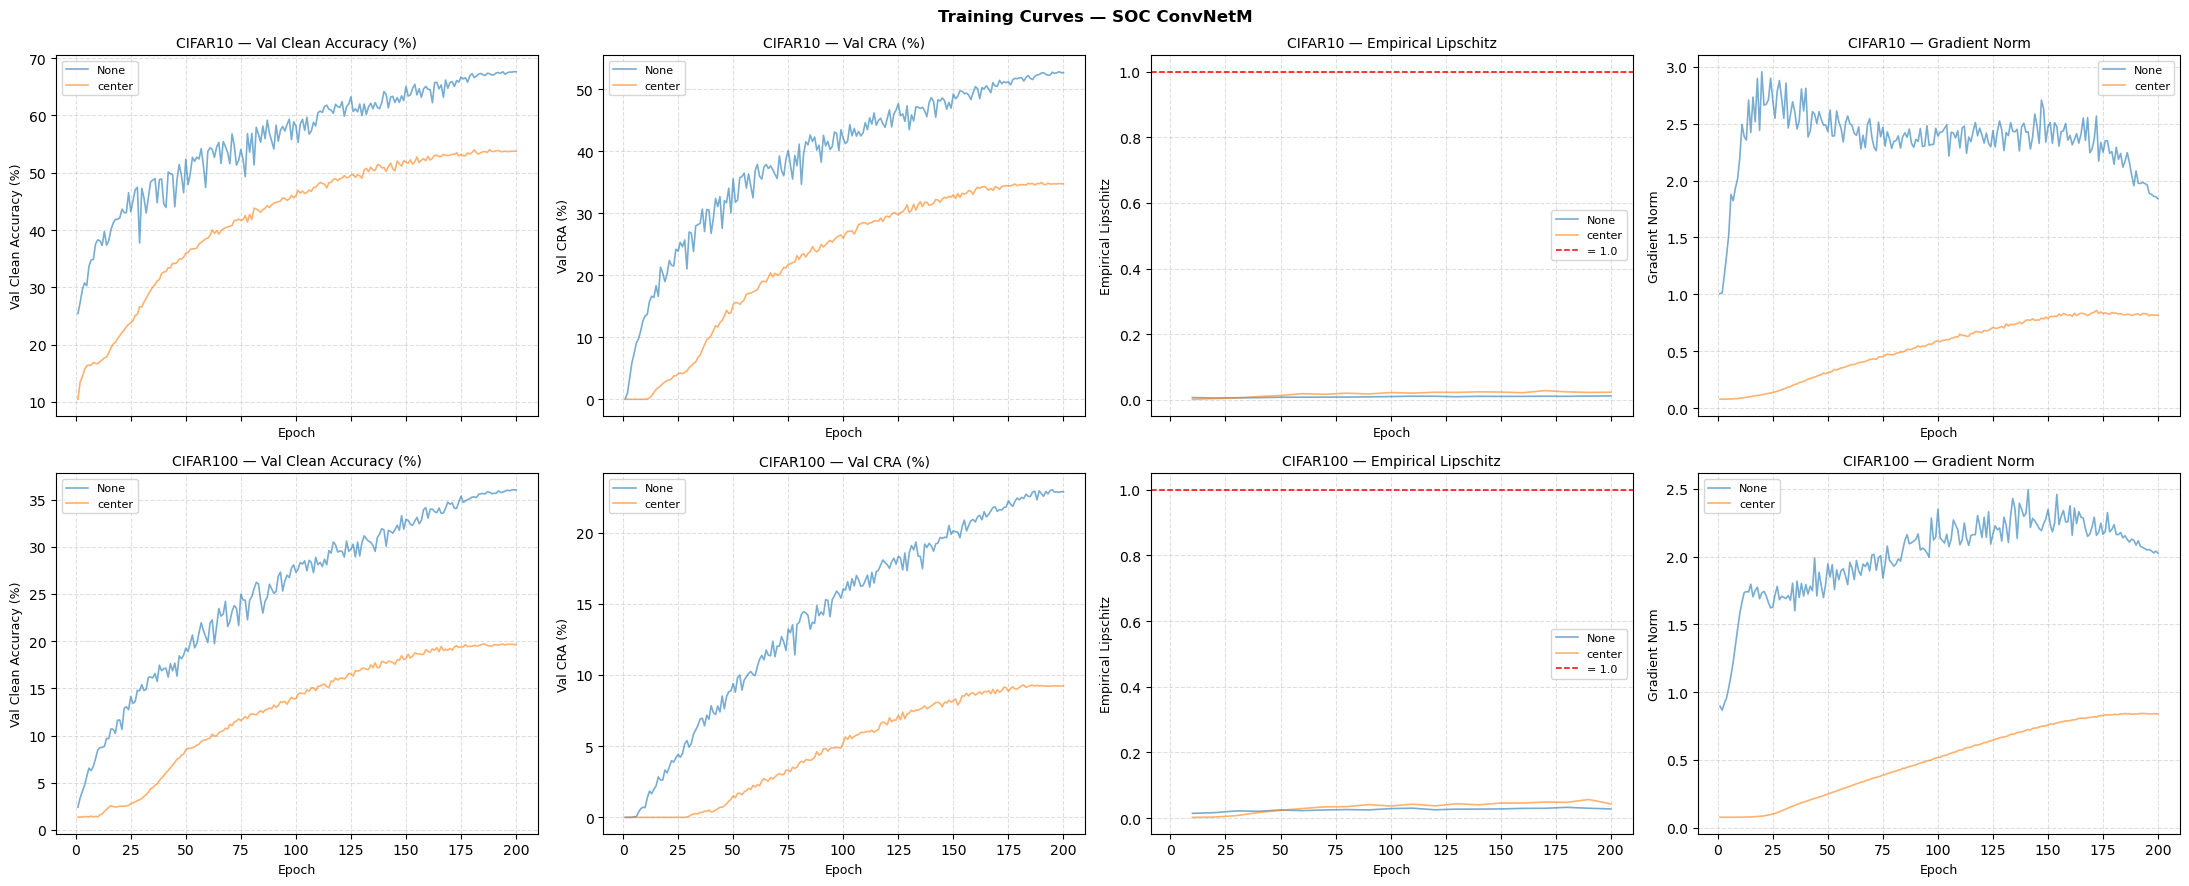

Saved: learning_curves.png


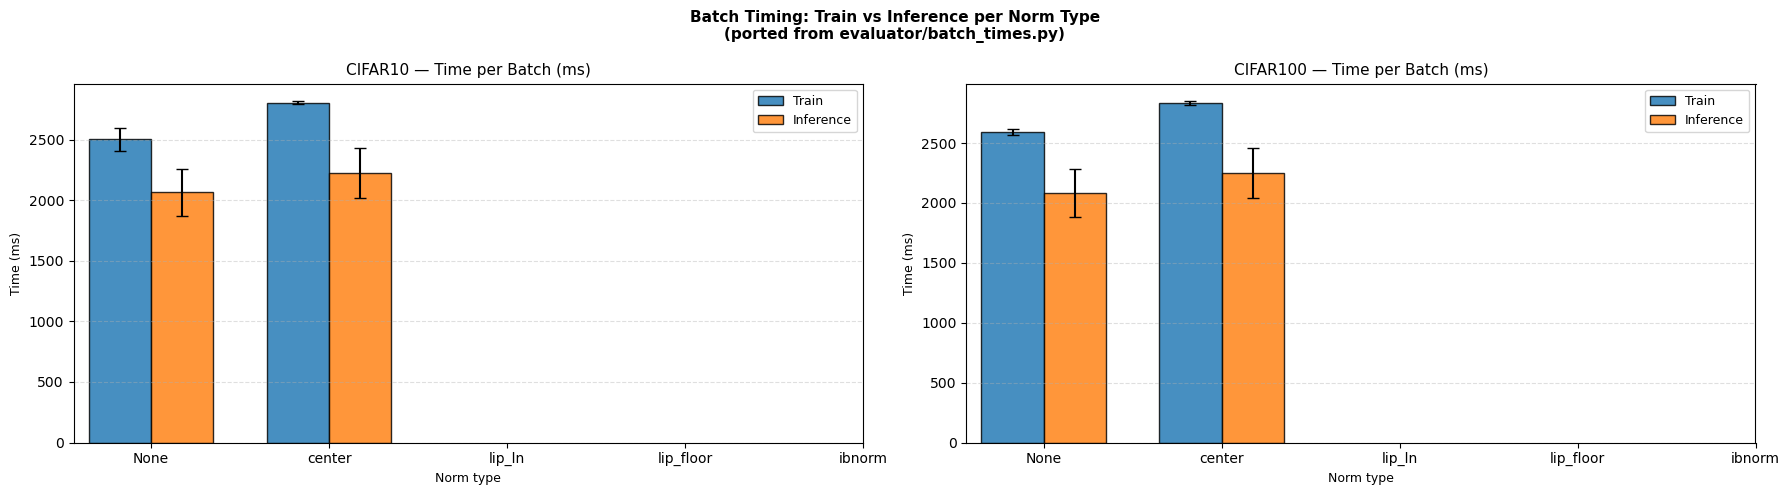

Saved: timing_comparison.png


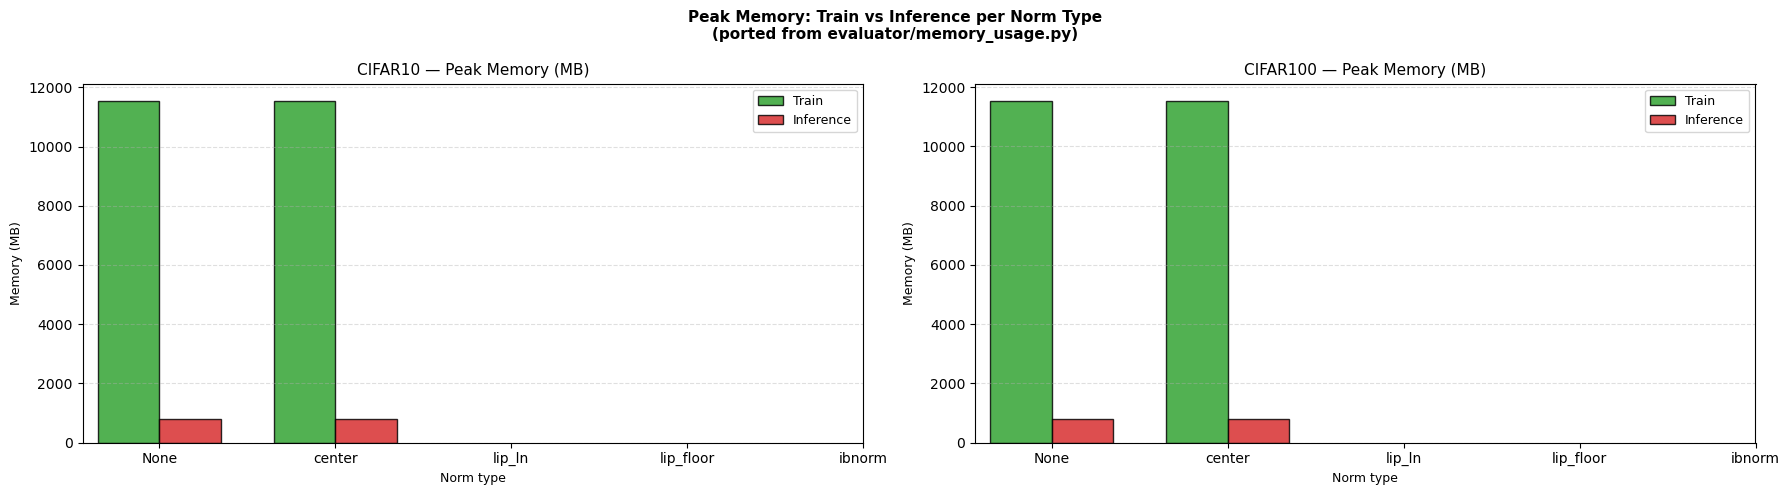

Saved: memory_comparison.png

✓  No collapsed or diverged runs (cifar10)

✓  No collapsed or diverged runs (cifar100)


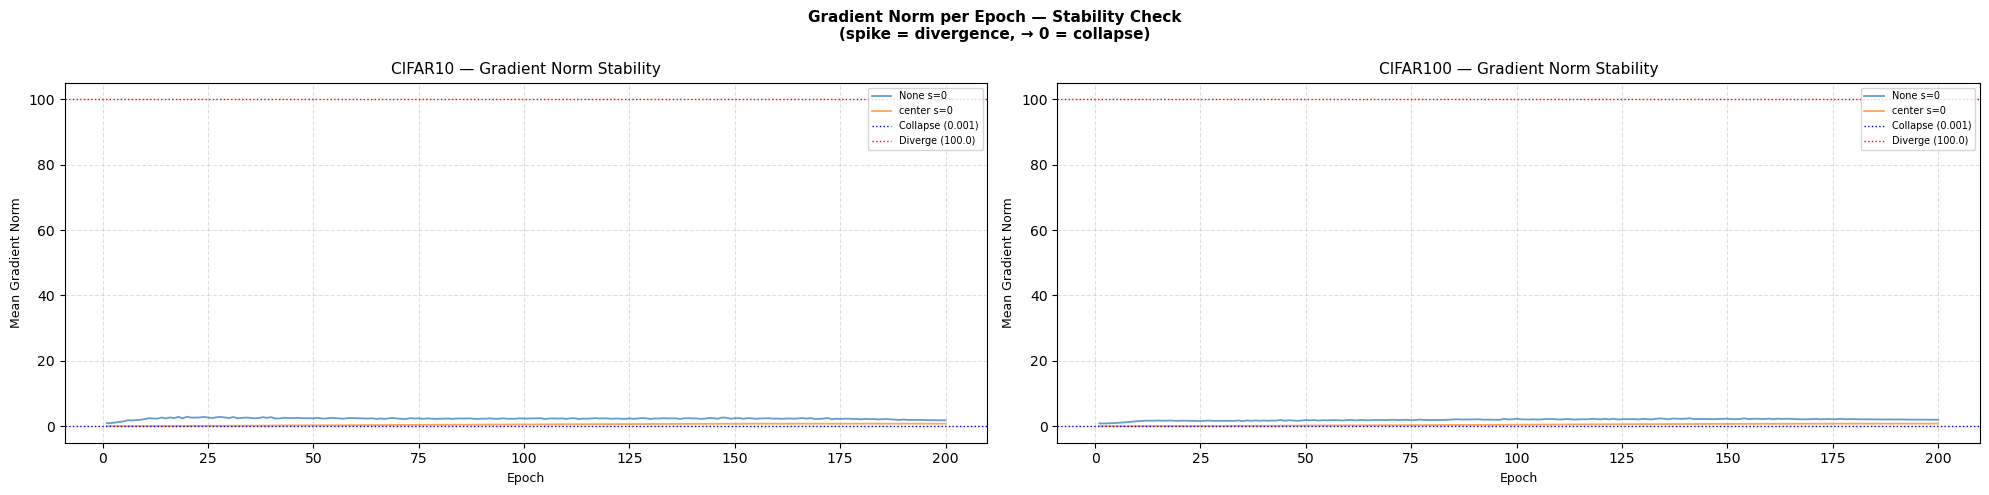

Saved: stability_check.png


In [14]:
norm_order = ['None', 'center', 'lip_ln', 'lip_floor', 'ibnorm']
colors     = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#d62728']
color_map  = dict(zip(norm_order, colors))

# ── Figure 1: Bar charts — all 6 metrics ──────────────────────────────────────
bar_metrics = [
    ('final_val_acc',   'Clean Accuracy (%)',      None),
    ('best_cra',        'Best CRA (%)',             None),
    ('final_emp_lip',   'Empirical Lipschitz',      1.0),
    ('final_grad_norm', 'Gradient Norm',            None),
    ('train_time_mean', 'Train Time/Batch (s)',     None),
    ('inf_time_mean',   'Inference Time/Batch (s)', None),
]

fig, axes = plt.subplots(2, 6, figsize=(32, 10))
fig.suptitle(
    'SOC ConvNetM — Norm Ablation  |  '
    'Block: SOCConv2d → Norm → MaxMin  |  ε=36/255',
    fontsize=12, fontweight='bold',
)

for col, (metric, ylabel, ref_line) in enumerate(bar_metrics):
    for row, dataset in enumerate(DATASETS):
        ax  = axes[row, col]
        sub = df[df['dataset'] == dataset]

        means, stds, labels_ = [], [], []
        for nt in norm_order:
            vals = sub[sub['norm_type'] == nt][metric].dropna().values
            means.append(vals.mean() if len(vals) > 0 else 0)
            stds.append(vals.std()   if len(vals) > 1 else 0)
            labels_.append(nt)

        x = np.arange(len(norm_order))
        ax.bar(x, means, yerr=stds, capsize=4,
               color=[color_map[l] for l in labels_],
               alpha=0.82, edgecolor='black', linewidth=0.6)

        for i, nt in enumerate(norm_order):
            vals = sub[sub['norm_type'] == nt][metric].dropna().values
            ax.scatter([i] * len(vals), vals,
                       color='black', zorder=3, s=14, alpha=0.7)

        if ref_line is not None:
            ax.axhline(ref_line, color='red', linestyle='--',
                       linewidth=1.1, label=f'= {ref_line}')
            ax.legend(fontsize=7)

        ax.set_xticks(x)
        ax.set_xticklabels(labels_, fontsize=8)
        ax.set_title(f'{dataset.upper()} — {ylabel}', fontsize=9)
        ax.set_ylabel(ylabel, fontsize=8)
        ax.set_xlabel('Norm type', fontsize=8)
        ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('./norm_ablation_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: norm_ablation_bar.png")


# ── Figure 2: Learning curves — accuracy, CRA, Lipschitz, grad norm ───────────
fig, axes = plt.subplots(2, 4, figsize=(22, 9), sharex=True)
fig.suptitle('Training Curves — SOC ConvNetM',
             fontsize=12, fontweight='bold')

curve_metrics = [
    ('val_accuracy',    'Val Clean Accuracy (%)', None),
    ('val_cra',         'Val CRA (%)',             None),
    ('empirical_lip',   'Empirical Lipschitz',     1.0),
    ('train_grad_norm', 'Gradient Norm',           None),
]

for col, (metric, ylabel, ref_line) in enumerate(curve_metrics):
    for row, dataset in enumerate(DATASETS):
        ax = axes[row, col]
        for norm_type in NORM_TYPES:
            nt_str = str(norm_type)
            for r in all_results:
                if r['dataset'] == dataset and r['norm_type'] == nt_str:
                    if metric == 'empirical_lip':
                        epochs_ = [h['epoch'] for h in r['history']
                                   if h['empirical_lip'] is not None]
                        vals_   = [h['empirical_lip'] for h in r['history']
                                   if h['empirical_lip'] is not None]
                    else:
                        epochs_ = [h['epoch'] for h in r['history']]
                        vals_   = [h[metric]  for h in r['history']]
                    if epochs_:
                        ax.plot(epochs_, vals_,
                                color=color_map[nt_str],
                                alpha=0.6, linewidth=1.2, label=nt_str)

        if ref_line is not None:
            ax.axhline(ref_line, color='red', linestyle='--',
                       linewidth=1.1, label=f'= {ref_line}')

        ax.set_title(f'{dataset.upper()} — {ylabel}', fontsize=10)
        ax.set_xlabel('Epoch', fontsize=9)
        ax.set_ylabel(ylabel, fontsize=9)
        ax.grid(linestyle='--', alpha=0.4)
        handles, lbls = ax.get_legend_handles_labels()
        unique = dict(zip(lbls, handles))
        ax.legend(unique.values(), unique.keys(), fontsize=8, loc='best')

plt.tight_layout()
plt.savefig('./learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: learning_curves.png")


# ── Figure 3: Timing — train vs inference per norm type ───────────────────────
fig, axes = plt.subplots(1, len(DATASETS), figsize=(9 * len(DATASETS), 5))
if len(DATASETS) == 1:
    axes = [axes]
fig.suptitle('Batch Timing: Train vs Inference per Norm Type\n'
             '(ported from evaluator/batch_times.py)',
             fontsize=11, fontweight='bold')

x     = np.arange(len(norm_order))
width = 0.35

for ax, dataset in zip(axes, DATASETS):
    sub = df[df['dataset'] == dataset]
    train_means, train_stds, inf_means, inf_stds = [], [], [], []
    for nt in norm_order:
        rows = sub[sub['norm_type'] == nt]
        train_means.append(rows['train_time_mean'].mean() * 1000)
        train_stds.append( rows['train_time_std'].mean()  * 1000)
        inf_means.append(  rows['inf_time_mean'].mean()   * 1000)
        inf_stds.append(   rows['inf_time_std'].mean()    * 1000)

    ax.bar(x - width/2, train_means, width, yerr=train_stds, capsize=4,
           label='Train', color='#1f77b4', alpha=0.82, edgecolor='black')
    ax.bar(x + width/2, inf_means,   width, yerr=inf_stds,   capsize=4,
           label='Inference', color='#ff7f0e', alpha=0.82, edgecolor='black')

    ax.set_xticks(x)
    ax.set_xticklabels(norm_order, fontsize=10)
    ax.set_title(f'{dataset.upper()} — Time per Batch (ms)', fontsize=11)
    ax.set_ylabel('Time (ms)', fontsize=9)
    ax.set_xlabel('Norm type', fontsize=9)
    ax.legend(fontsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('./timing_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: timing_comparison.png")


# ── Figure 4: Memory — train vs inference per norm type ───────────────────────
fig, axes = plt.subplots(1, len(DATASETS), figsize=(9 * len(DATASETS), 5))
if len(DATASETS) == 1:
    axes = [axes]
fig.suptitle('Peak Memory: Train vs Inference per Norm Type\n'
             '(ported from evaluator/memory_usage.py)',
             fontsize=11, fontweight='bold')

for ax, dataset in zip(axes, DATASETS):
    sub = df[df['dataset'] == dataset]
    train_mems, inf_mems = [], []
    for nt in norm_order:
        rows = sub[sub['norm_type'] == nt]
        train_mems.append(rows['train_memory_bytes'].mean() / 1e6)
        inf_mems.append(  rows['inf_memory_bytes'].mean()   / 1e6)

    ax.bar(x - width/2, train_mems, width, capsize=4,
           label='Train', color='#2ca02c', alpha=0.82, edgecolor='black')
    ax.bar(x + width/2, inf_mems,   width, capsize=4,
           label='Inference', color='#d62728', alpha=0.82, edgecolor='black')

    ax.set_xticks(x)
    ax.set_xticklabels(norm_order, fontsize=10)
    ax.set_title(f'{dataset.upper()} — Peak Memory (MB)', fontsize=11)
    ax.set_ylabel('Memory (MB)', fontsize=9)
    ax.set_xlabel('Norm type', fontsize=9)
    ax.legend(fontsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('./memory_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: memory_comparison.png")


# ── Figure 5: Gradient norm stability check ───────────────────────────────────
COLLAPSE_THRESHOLD = 1e-3
DIVERGE_THRESHOLD  = 100.0

fig, axes = plt.subplots(1, len(DATASETS), figsize=(10 * len(DATASETS), 5))
if len(DATASETS) == 1:
    axes = [axes]
fig.suptitle('Gradient Norm per Epoch — Stability Check\n'
             '(spike = divergence, → 0 = collapse)',
             fontsize=11, fontweight='bold')

for ax, dataset in zip(axes, DATASETS):
    flagged = []
    for norm_type in NORM_TYPES:
        nt_str = str(norm_type)
        for r in all_results:
            if r['dataset'] == dataset and r['norm_type'] == nt_str:
                epochs_    = [h['epoch']          for h in r['history']]
                grad_norms = [h['train_grad_norm'] for h in r['history']]
                ax.plot(epochs_, grad_norms,
                        color=color_map[nt_str],
                        alpha=0.7, linewidth=1.3,
                        label=f"{nt_str} s={r['seed']}")
                if any(g < COLLAPSE_THRESHOLD for g in grad_norms):
                    flagged.append(f"COLLAPSE: {nt_str} seed={r['seed']}")
                if any(g > DIVERGE_THRESHOLD for g in grad_norms):
                    flagged.append(f"DIVERGED: {nt_str} seed={r['seed']}")

    ax.axhline(COLLAPSE_THRESHOLD, color='blue', linestyle=':',
               linewidth=1.0, label=f'Collapse ({COLLAPSE_THRESHOLD})')
    ax.axhline(DIVERGE_THRESHOLD,  color='red',  linestyle=':',
               linewidth=1.0, label=f'Diverge ({DIVERGE_THRESHOLD})')
    ax.set_title(f'{dataset.upper()} — Gradient Norm Stability', fontsize=11)
    ax.set_xlabel('Epoch', fontsize=9)
    ax.set_ylabel('Mean Gradient Norm', fontsize=9)
    ax.grid(linestyle='--', alpha=0.4)
    ax.legend(fontsize=7, loc='upper right')

    if flagged:
        print(f"\n⚠️  Flagged runs ({dataset}):")
        for f_ in flagged:
            print(f"    {f_}")
    else:
        print(f"\n✓  No collapsed or diverged runs ({dataset})")

plt.tight_layout()
plt.savefig('./stability_check.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: stability_check.png")

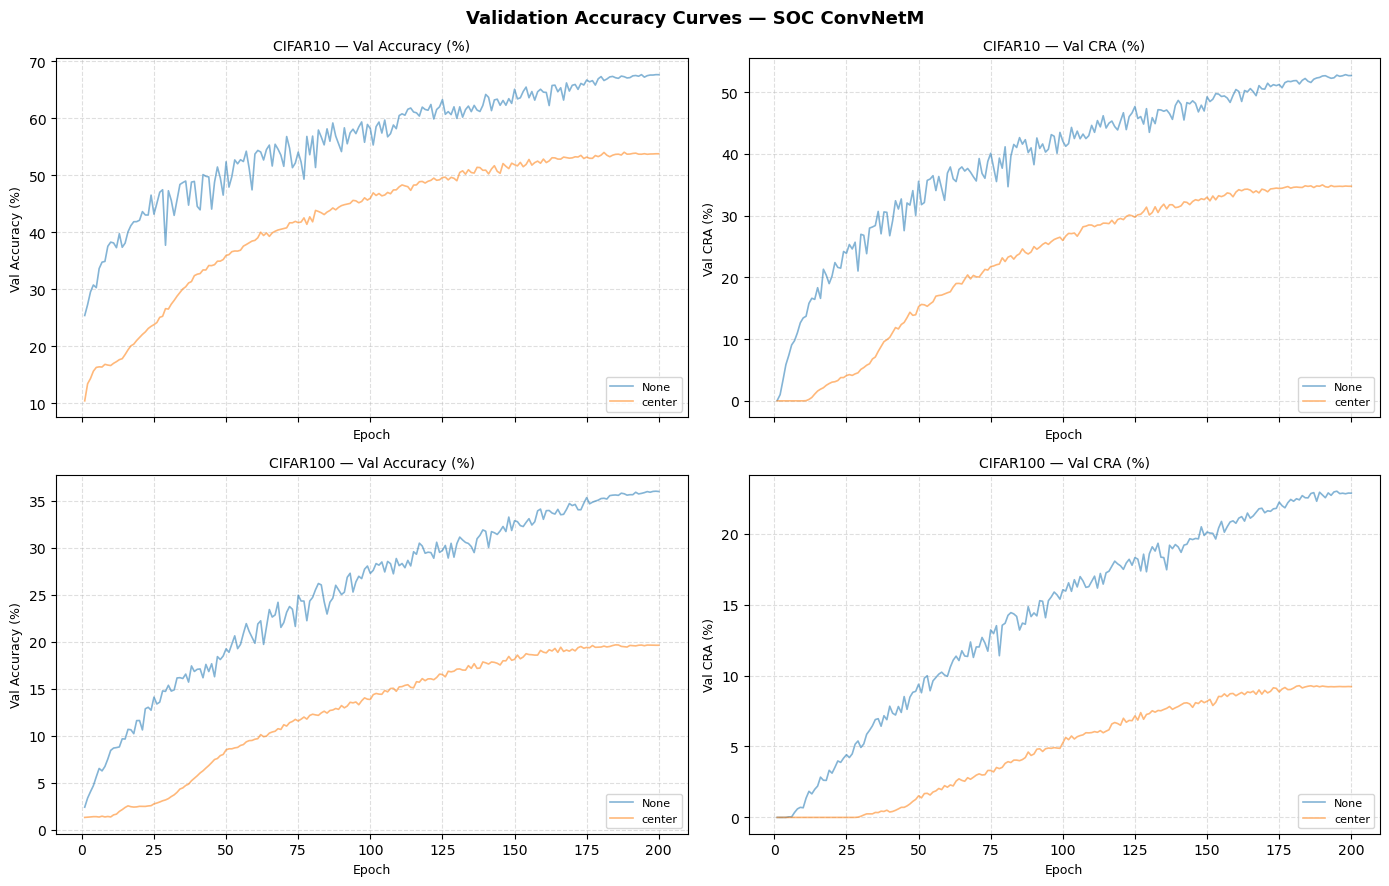

Saved: learning_curves.png


In [15]:
# ── Learning curves (val accuracy over epochs) ───────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
fig.suptitle('Validation Accuracy Curves — SOC ConvNetM', fontsize=13, fontweight='bold')

metrics_curve = [
    ('val_accuracy', 'Val Accuracy (%)'),
    ('val_cra',      'Val CRA (%)'),
]

for col, (metric, ylabel) in enumerate(metrics_curve):
    for row, dataset in enumerate(DATASETS):
        ax = axes[row, col]
        for norm_type in NORM_TYPES:
            nt_str = str(norm_type)
            for r in all_results:
                if r['dataset'] == dataset and r['norm_type'] == nt_str:
                    epochs_ = [h['epoch']  for h in r['history']]
                    vals_   = [h[metric]   for h in r['history']]
                    ax.plot(epochs_, vals_, color=color_map[nt_str],
                            alpha=0.55, linewidth=1.2, label=nt_str)

        ax.set_title(f'{dataset.upper()} — {ylabel}', fontsize=10)
        ax.set_xlabel('Epoch', fontsize=9)
        ax.set_ylabel(ylabel, fontsize=9)
        ax.grid(linestyle='--', alpha=0.4)
        # Deduplicated legend
        handles, lbls = ax.get_legend_handles_labels()
        unique = dict(zip(lbls, handles))
        ax.legend(unique.values(), unique.keys(), fontsize=8, loc='lower right')

plt.tight_layout()
plt.savefig('./learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: learning_curves.png")

## Cell 14 — Final summary printout

In [16]:
print("\n" + "="*110)
print(" FINAL RESULTS — SOC ConvNetM Norm Ablation")
print("="*110)
print(f" {'Dataset':>10}  {'Norm':>8}  {'Clean Acc':>14}  {'CRA':>14}  "
      f"{'Emp.Lip':>10}  {'GradNorm':>10}  "
      f"{'Train t/batch':>16}  {'Inf t/batch':>14}  "
      f"{'Train Mem':>10}  {'Inf Mem':>10}")
print("-"*110)

for _, row in summary_table.iterrows():
    print(f" {row['dataset']:>10}  {row['norm_type']:>8}  "
          f"{row['Clean Acc']:>14}  {row['CRA']:>14}  "
          f"{row['Emp. Lip']:>10}  {row['Grad Norm']:>10}  "
          f"{row['Train t/batch']:>16}  {row['Inf t/batch']:>14}  "
          f"{row['Train Mem']:>10}  {row['Inf Mem']:>10}")

print("="*110)
print(f"\nε = {EPSILON:.5f} ({36}/255)  |  Optimizer: SGD momentum=0.9  |  Loss: HKR")
print("Block: SOCConv2d(3×3) → NormLayer → MaxMin  [Position A]")
print("Timing : ported from evaluator/batch_times.py  "
      "(first batch skipped as warm-up)")
print("Memory : ported from evaluator/memory_usage.py "
      "(peak CUDA / tracemalloc on CPU)")
print("\nOutput files:")
for fname in ['all_runs.csv', 'summary_table.csv',
              'norm_ablation_bar.png', 'learning_curves.png',
              'timing_comparison.png', 'memory_comparison.png',
              'stability_check.png', 'results_checkpoint.json']:
    print(f"  ./{fname}")


 FINAL RESULTS — SOC ConvNetM Norm Ablation
    Dataset      Norm       Clean Acc             CRA     Emp.Lip    GradNorm     Train t/batch     Inf t/batch   Train Mem     Inf Mem
--------------------------------------------------------------------------------------------------------------
    cifar10      None           67.63           52.85      0.0121      1.8393  2502.5 ± 95.1 ms  2065.6 ± 195.5 ms    11.54 GB   810.81 MB
    cifar10    center           53.77           34.99      0.0235      0.8147  2806.1 ± 14.3 ms  2224.2 ± 208.7 ms    11.54 GB   811.86 MB
   cifar100      None           36.01           23.00      0.0281      2.0246  2592.7 ± 22.8 ms  2083.9 ± 197.1 ms    11.54 GB   810.81 MB
   cifar100    center           19.65            9.29      0.0436      0.8404  2834.7 ± 18.0 ms  2252.9 ± 209.4 ms    11.54 GB   810.81 MB

ε = 0.14118 (36/255)  |  Optimizer: SGD momentum=0.9  |  Loss: HKR
Block: SOCConv2d(3×3) → NormLayer → MaxMin  [Position A]
Timing : ported from evalua